In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from braindecode.preprocessing import create_fixed_length_windows
from utils.TUEP import TUHEpilepsy
import mne
from copy import deepcopy, copy
import sys

from braindecode.preprocessing.preprocess import Preprocessor, preprocess as preprocess_bc

pd.set_option("display.max_rows", None)#
pd.set_option("display.max_columns", None)
np.set_printoptions(threshold=1000, edgeitems=20, linewidth=1000)   


In [2]:
EPILEPSY_PATH='/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy'

tuep=TUHEpilepsy(path=EPILEPSY_PATH,set_montage=False,rename_channels=True,target_name='epilepsy', n_jobs=2, preload=False)

# Old Script

In [ ]:
def select_by_duration(dataset,tmin=10):
    new_dataset=deepcopy(dataset)
    new_dataset.datasets=[sample for sample in dataset.datasets if sample.raw.n_times/sample.raw.info['sfreq'] >= tmin]
    return new_dataset

def select_by_channel(dataset,channels):
    new_dataset=deepcopy(dataset)
    new_dataset.datasets=[sample for sample in dataset.datasets if set(channels).issubset(ch_name.upper() for ch_name in sample.raw.ch_names)]
    return new_dataset

channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']

def preprocess(in_dataset, target_freq=None, photic_ph=True):
    dataset=deepcopy(in_dataset)
    if photic_ph:
        channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
    else:
        channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']
        
    for i, sample in enumerate(dataset.datasets):
        #if sample.raw.n_times/sample.raw.info['sfreq'] < 10:        #discard samples shorter than 10s
        #    print(f"Discarding {i} because it is shorter than 10s")
        #    dataset.datasets.pop(i)
        #    continue
        #sample.raw.ch_names.upper()
        if set(channels[:-1]).issubset(ch_name.upper() for ch_name in sample.raw.ch_names) == False:
            print(f"Channels missing in {i}")
            print(set(channels) - set(sample.raw.ch_names))
            continue

        sample.raw.rename_channels(lambda x: x.upper(),verbose=False)
        
        #check for PHOTIC PH channel
        if 'PHOTIC PH' in sample.raw.ch_names and photic_ph == True:
            #set the channel type to stim
            sample.raw.set_channel_types({'PHOTIC PH': 'stim'}, on_unit_change="ignore")
        elif 'PHOTIC PH' not in sample.raw.ch_names and photic_ph == True: 
            sample.raw.load_data()
            sample.raw.add_channels([mne.io.RawArray(np.zeros((1, sample.raw.n_times)), mne.create_info(['PHOTIC PH'], sample.raw.info['sfreq'], ['stim']), verbose=False)],force_update_info=True)
            print(f"Added PHOTIC PH channel to {i}")

        sample.raw.pick(channels)
        sample.raw.reorder_channels(channels)
        sample.raw.filter(0.1,(sample.raw.info['sfreq']/2)-0.1,verbose=False, n_jobs=8, l_trans_bandwidth=0.1)
        #sample.raw.filter(0.1,(target_freq/2)-0.1,verbose=False, n_jobs=8, l_trans_bandwidth=0.1)
        sample.raw.notch_filter(60,verbose=False, n_jobs=8)

        if sample.raw.info['sfreq'] != target_freq and target_freq is not None:
            sample.raw.resample(target_freq, n_jobs=8)
            print(f"Resampled {i} to {target_freq} Hz")

    return dataset

tuep_test=preprocess(tuep, target_freq=250, photic_ph=True)

tuep_test=select_by_channel(tuep_test,channels)

tuep_test=select_by_duration(tuep_test, tmin=10)

# savedir='/space/gzanardini/tuh_eeg/preprocessed/fullv2/'
# tuep_test.save(savedir, overwrite=True)

# New 

In [3]:
def remove_calibration_signal(eeg, amplitude, threshold=1):
    for t in range(eeg.shape[1]):
        if np.abs(eeg[19, t]) < amplitude - threshold:
            start = t
            break
        else:
            start = 0
    return eeg[:, start:]

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']


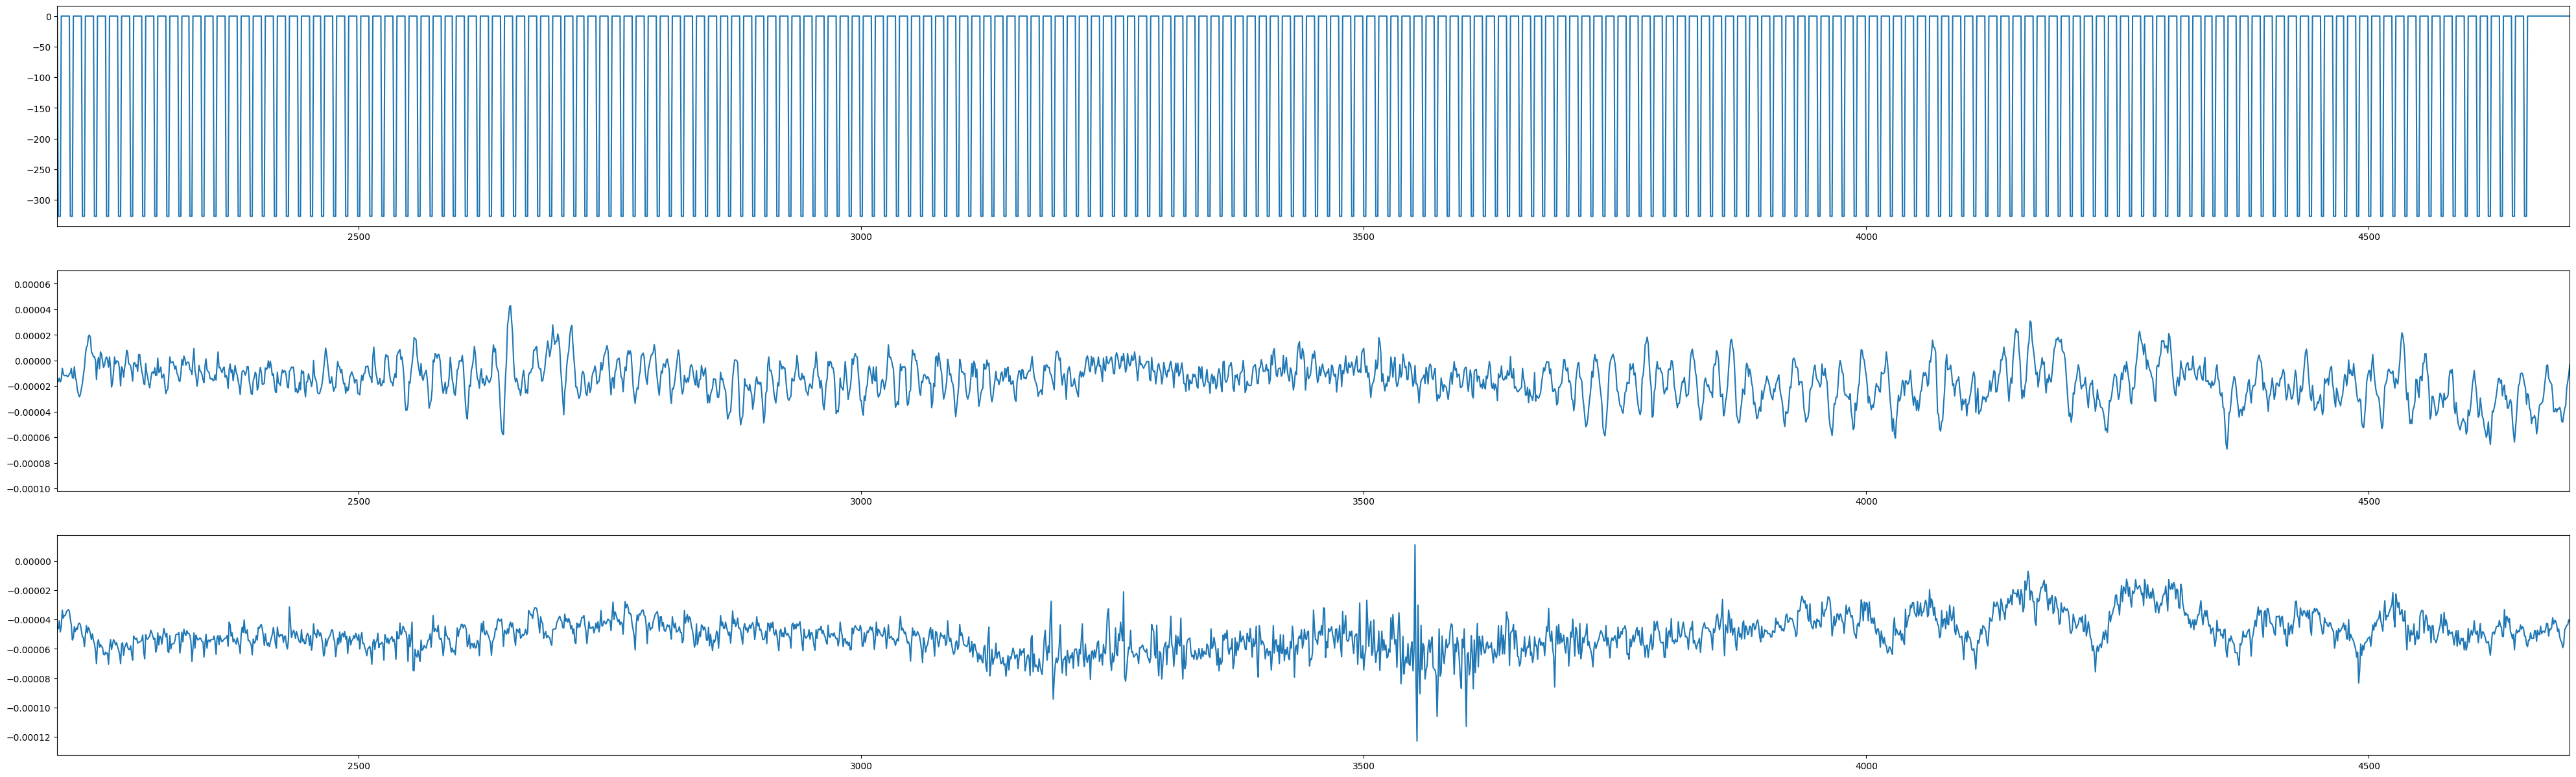

path        /space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....
version                                                v2.0.3
year                                                     2003
month                                                       1
day                                                         1
subject                                              aaaaabju
session                                                     1
segment                                                     1
age                                                        64
gender                                                      F
epilepsy                                                    0
Name: 6, dtype: object


In [4]:
index=6

lower=2200
upper=lower+2500

plt.figure(figsize=(50,15))
plt.subplot(311)
plt.plot(tuep.datasets[index].raw['PHOTIC PH'][0][0])
plt.xlim(lower,upper)

print(tuep.datasets[index].raw.ch_names)
plt.subplot(312)
plt.plot(tuep.datasets[index].raw['O2'][0][0])
plt.xlim(lower,upper)

plt.subplot(313)
plt.plot(tuep.datasets[index].raw['T3'][0][0])
plt.xlim(lower,upper)
plt.show()

print(tuep.description.loc[index])

In [6]:
samples_to_discard = {
    "aaaaabju": {"session": 1, "segment": 0},
    "aaaaaflb": {"session": 1, "segment": 0},
    "aaaaagxr": {"session": 1, "segment": 1},
    "aaaaajgn": {"session": 1, "segment": 0},
    "aaaaajrh": {"session": 2, "segment": 0}
}

In [7]:
def preproc_photostim(dataset, fs_target=250):

    channels = ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz',
                'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']

    channels_dict = {ch: 'eeg' for ch in channels[:-1]}
    channels_dict['PHOTIC PH'] = 'stim'

    new_df=pd.DataFrame(index=range(100), columns=dataset.description.columns) 
    samples_with_stim=[]
    ctr=0
    for i, recording in enumerate(dataset.datasets):

    #discard samples which perfectly match the samples_to_discard
        if recording.description['subject'] in samples_to_discard.keys():
            if recording.description['session'] == samples_to_discard[recording.description['subject']]['session']:        
                if recording.description['segment'] == samples_to_discard[recording.description['subject']]['segment']:
                    print(f"##### Discarding {recording.description['subject']} - {recording.description['session']} - {recording.description['segment']}")
                    continue

        if 'PHOTIC PH' in recording.raw.ch_names:
            recording.raw.pick(channels)
            recording.raw.reorder_channels(channels)
            recording.raw.set_channel_types(channels_dict, on_unit_change="warn")

            temp=remove_calibration_signal(recording.raw.get_data(), 100)
            temp[19]=temp[19]*1e-6

            if not np.all(temp[19] == 0) and temp.shape[1]*1/recording.raw.info['sfreq']>=30:

                #make a new raw object with the new data
                recording.raw=mne.io.RawArray(temp, recording.raw.info, verbose=False)
                #if not np.all(recording.raw['PHOTIC PH'][0][0] == 0) and recording.raw.last_samp*1/recording.raw.info['sfreq']>=30:
                #print(f'Length of recording {i} : {recording.raw.last_samp*1/recording.raw.info["sfreq"]}')
                
                recording.raw.notch_filter(60,verbose=False, n_jobs=8)

                if recording.raw.info['sfreq'] != fs_target and fs_target is not None:
                    recording.raw.resample(fs_target, n_jobs=8)
                    print(f"Resampled {i} to {fs_target} Hz")

                samples_with_stim.append(recording.raw)
                new_df.loc[ctr]=dataset.description.loc[i]
                ctr+=1

    new_df=new_df.dropna()

    return new_df, samples_with_stim

stim_df, stim_samples=preproc_photostim(tuep, fs_target=250)

print(len(stim_df), len(stim_samples))

/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning

##### Discarding aaaaabju - 1 - 0


/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning

##### Discarding aaaaaflb - 1 - 0


/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")


...

/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning

##### Discarding aaaaajrh - 2 - 0


/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning

40 40


/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")
/tmp/ipykernel_2802455/1332208244.py:24: RuntimeWarning: The unit for channel(s) PHOTIC PH has changed from NA to V.
  recording.raw.set_channel_types(channels_dict, on_unit_change="warn")


In [8]:
import pickle as pkl
with open('photostimulation/temp_data/stim_samples.pkl', 'wb') as f:
    pkl.dump(stim_samples, f)

stim_df.to_csv('photostimulation/temp_data/stim_df.csv', index=False)

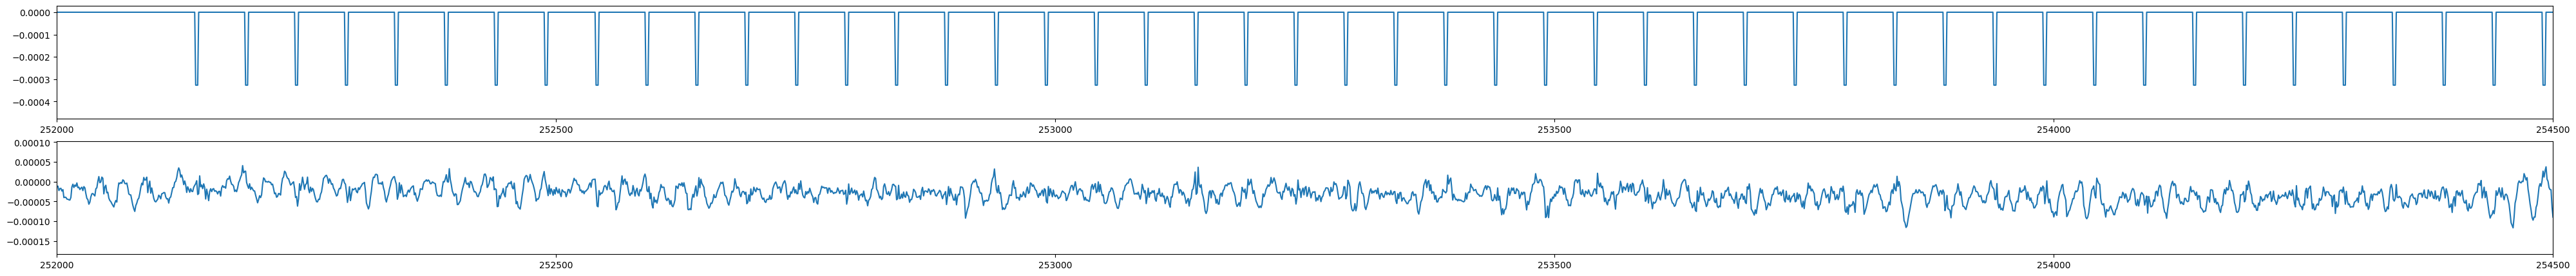

In [10]:
lower=252000
upper = lower+2500
idx=1
plt.figure(figsize=(50,5))
plt.subplot(211)
plt.plot(stim_samples[idx]['PHOTIC PH'][0][0])
plt.xlim(lower, upper)
plt.subplot(212)
plt.plot(stim_samples[idx]['O2'][0][0])
plt.xlim(lower, upper)
plt.show()


Length of the sample 0: 1214.0
Channel order: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
Start: 231858, End: 284802, Length: 211.776
Length of the sample 1: 1329.0
Channel order: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
Start: 241879, End: 299851, Length: 231.888
Length of the sample 2: 1488.056
Channel order: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
Start: 265856, End: 318828, Length: 211.888
Length of the sample 3: 1194.0
Channel order: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']
Start: 224513, End: 277468, Length: 211.82
Length of the sample 4: 389.0
Channel order: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2',

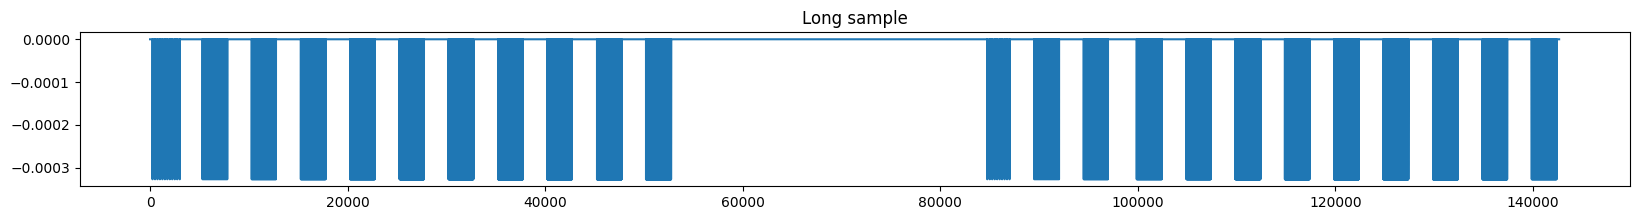

1st part: Start: 0, End: 52498
First part: 52748
Sanity check length: 52748


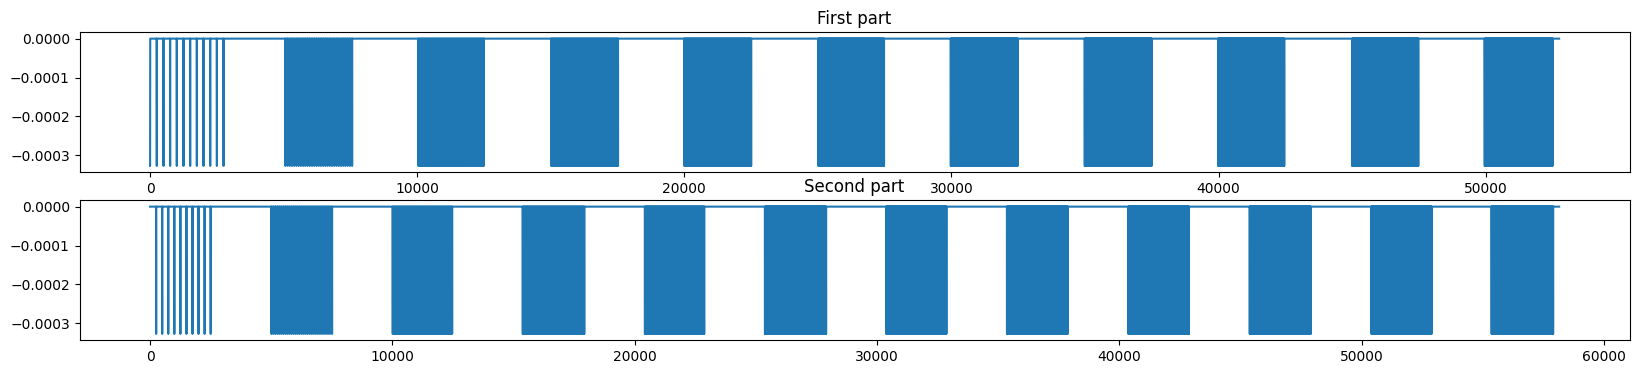

SANITY CHECK
Length of the photostimulation periods:  41
Length of the windows descriptions:  41


In [12]:
photostim_periods = []
no_photostim_periods=[]
intervals=[]

wins_df=pd.DataFrame(index=range(150), columns=stim_df.columns)
no_ph_df=pd.DataFrame(index=range(150), columns=stim_df.columns)

for i, edf in enumerate(stim_samples):

    sample=edf.get_data()
    print(f'Length of the sample {i}: {sample.shape[1]/250}')
    print(f'Channel order: {edf.ch_names}')

    for t in range(sample.shape[1]): # find the first non-zero value
        if np.abs(sample[19, t]) > 0:
            start = t
            break
    for t in range(sample.shape[1]-1, 0, -1): # find the last non-zero value
        if np.abs(sample[19, t]) > 0:
            end = t
            break

    start-=250 # add 1s before the first non-zero value
    end+=250 # add 1s after the last non-zero value

    temp=sample[:, start:end] # get the segment

    print(f'Start: {start}, End: {end}, Length: {temp.shape[1]/250}')
    intervals.append((start, end))
    '''
    print('Length of the segment - sample :',i,' ', (end-start)/250)
    plt.figure(figsize=(10, 2))
    plt.title(f'Subject: {photostim_df.loc[i]['subject']} - Session: {photostim_df.loc[i]['session']} - Segment {photostim_df.loc[i]['segment']} - Epilepsy: {photostim_df.loc[i]['epilepsy']}')
    plt.plot(temp[19,:])
    plt.show()'''

    photostim_periods.append(temp)
    wins_df.loc[i]=stim_df.loc[i]

    del temp

    temp1=sample[:, :start]
    temp2=sample[:, end:]
    temp=np.concatenate((temp1, temp2), axis=1)

    no_photostim_periods.append(temp)
    no_ph_df.loc[i]=stim_df.loc[i]

    del temp1, temp2, temp

#duplicate .iloc[10] since the recording has 2 different photostimulation periods
temp_df=wins_df.copy().iloc[:11]
temp_df2=wins_df.copy().iloc[10:]

wins_df=pd.concat([temp_df, temp_df2], ignore_index=True, axis=0)
wins_df.dropna(inplace=True)

print('Length of the photostimulation periods: ',len(photostim_periods))
print('Length of the windows descriptions: ',len(wins_df))

long_sample=copy(photostim_periods[10])

for t in range(long_sample.shape[1]):
    if np.abs(long_sample[19, t]) > 0:
        start = t
        break
for t in range(long_sample.shape[1]-1, 0, -1):
    end=long_sample.shape[1]
    if np.abs(long_sample[19, t]) > 0:
        end = t
        break

midpoint = (start+end)//2
first_part = copy(long_sample[:, start:midpoint+250])
second_part = copy(long_sample[:, midpoint-250:end+250])

print(f'FULL SAMPLE - Start: {start}, End: {end}, Midpoint: {midpoint}')

plt.figure(figsize=(20, 2))
plt.plot(long_sample[19,:])
plt.title('Long sample')
plt.show()

for t in range(first_part.shape[1]):
    if np.abs(first_part[19, t]) > 0:
        start = t
        break
for t in range(first_part.shape[1]-1, 0, -1):
    if np.abs(first_part[19, t]) > 0:
        end = t
        break

print(f'1st part: Start: {start}, End: {end}')

end1=end+250

first_part = copy(first_part[:, start:end1])

print('First part:', first_part.shape[1])
print(f'Sanity check length: {(end1-start)}')

for t in range(second_part.shape[1]):
    if np.abs(second_part[19, t]) > 0:
        start = t
        break
for t in range(second_part.shape[1]-1, 0, -1):
    if np.abs(second_part[19, t]) > 0:
        end = t
        break

second_part = copy(second_part[:, start-250:end+250])

plt.figure(figsize=(20, 4))
plt.subplot(2, 1, 1)
plt.plot(first_part[19,:])
plt.title('First part')
plt.subplot(2, 1, 2)
plt.plot(second_part[19,:])
plt.title('Second part')
plt.show()

photostim_periods[10]=first_part
photostim_periods.insert(11, second_part)

print('SANITY CHECK')
print('Length of the photostimulation periods: ',len(photostim_periods))
print('Length of the windows descriptions: ',len(wins_df))

In [13]:
import pickle
import os

no_ph_df.dropna(inplace=True)

print('Number of samples with photic stimulation:', len(no_photostim_periods))
print('Length of the photostimulation descriptions: ',len(no_ph_df))

# Create the directory if it does not exist
# Save no_photostim_periods
with open('photostimulation/data/no_photostim_periods.pkl', 'wb') as f:
    pickle.dump(no_photostim_periods, f)

no_ph_df.to_csv('photostimulation/data/no_photostim.csv')

Number of samples with photic stimulation: 40
Length of the photostimulation descriptions:  40


In [28]:
from scipy.signal import spectrogram, find_peaks

def rto(x):
    return int(round((x + 1) / 2) * 2 - 1)

photostim_chunks= []
chunk_length=19.3
chunk_samples=int(chunk_length*250)

chunks_df=pd.DataFrame(index=range(470), columns=wins_df.columns)
# add a 'frequency; column
chunks_df['frequency']=np.nan
ctr=0

for i in range(len(photostim_periods)):

    # if i != 33:
    #     plt.figure(figsize=(20, 2))
    #     plt.plot(photostim_periods[i][19])
    #     plt.title(f'Sample: {i} - Subject: {wins_df.loc[i]["subject"]} - Session: {wins_df.loc[i]["session"]} - Segment {wins_df.loc[i]["segment"]} - Epilepsy: {wins_df.loc[i]["epilepsy"]}')
    #     plt.show()

    if i==35:
        continue

    for t in range(100, photostim_periods[i].shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        
        if t+chunk_samples <= photostim_periods[i].shape[1]:
            temp=photostim_periods[i][:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=photostim_periods[i][:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 0:
                start = abc - 25
                break

        '''
        for abc in range(temp.shape[1]-1, 0, -1): # find the last non-zero value
            if np.abs(temp[19, abc]) > 1:
                end = abc
                break
        '''

        end = start + 2550        
        temp=copy(temp[:, start:end])

        # if i != 33:
        #     print(i)
        #     plt.figure(figsize=(7, 2))
        #     plt.title(f'Sample: {i} - Chunk: {ctr} - Subject: {wins_df.loc[i]["subject"]} - Session: {wins_df.loc[i]["session"]} - Segment {wins_df.loc[i]["segment"]} - Epilepsy: {wins_df.loc[i]["epilepsy"]}')
        #     plt.plot(temp[19])
        #     plt.show()

        numpeaks=find_peaks(abs(temp[19]))[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.

        if np.ceil(stim_freq) % 2 == 0:
            stim_freq_round=rto(stim_freq+1)

        stim_freq_round=rto(stim_freq)

        print(f'Sample: {i} - Chunk: {ctr} - Frequency: {stim_freq_round} ')

        photostim_chunks.append(temp)

        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round

        ctr+=1

print('Length of the photostimulation chunks: ',len(photostim_chunks))
print('Length of the chunks descriptions: ',len(chunks_df))

Sample: 0 - Chunk: 0 - Frequency: 1 
Sample: 0 - Chunk: 1 - Frequency: 3 
Sample: 0 - Chunk: 2 - Frequency: 5 
Sample: 0 - Chunk: 3 - Frequency: 7 
Sample: 0 - Chunk: 4 - Frequency: 9 
Sample: 0 - Chunk: 5 - Frequency: 11 
Sample: 0 - Chunk: 6 - Frequency: 13 
Sample: 0 - Chunk: 7 - Frequency: 15 
Sample: 0 - Chunk: 8 - Frequency: 17 
Sample: 0 - Chunk: 9 - Frequency: 19 
Sample: 0 - Chunk: 10 - Frequency: 21 
Sample: 1 - Chunk: 11 - Frequency: 13 
Sample: 1 - Chunk: 12 - Frequency: 3 
Sample: 1 - Chunk: 13 - Frequency: 5 
Sample: 1 - Chunk: 14 - Frequency: 7 
Sample: 1 - Chunk: 15 - Frequency: 9 
Sample: 1 - Chunk: 16 - Frequency: 11 
Sample: 1 - Chunk: 17 - Frequency: 13 
Sample: 1 - Chunk: 18 - Frequency: 15 
Sample: 1 - Chunk: 19 - Frequency: 17 
Sample: 1 - Chunk: 20 - Frequency: 19 
Sample: 1 - Chunk: 21 - Frequency: 21 
Sample: 1 - Chunk: 22 - Frequency: 23 
Sample: 2 - Chunk: 23 - Frequency: 21 
Sample: 2 - Chunk: 24 - Frequency: 1 
Sample: 2 - Chunk: 25 - Frequency: 15 
Sample

In [29]:
odd_one=photostim_periods[35]

chunk_length=19.8
chunk_samples=int(chunk_length*250)

ctr=450
i=35

first_part=copy(odd_one[:, :45000])
second_part=copy(odd_one[:, 45000:])

for t in range(200, first_part.shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        if t+chunk_samples <= first_part.shape[1]:
            temp=first_part[:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=first_part[:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 0:
                start = abc - 25
                break
 
        end = start + 2550
        
        temp=copy(temp[:, start:end])

        '''plt.figure(figsize=(7, 2))
        plt.plot(temp[19])
        plt.show()'''

        numpeaks=find_peaks(abs(temp[19]))[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.
        if np.ceil(stim_freq) % 2 == 0:
            stim_freq_round=rto(stim_freq+1)

        photostim_chunks.append(temp)
        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round
        ctr+=1

for t in range(100, second_part.shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        if t+chunk_samples <= second_part.shape[1]:
            temp=second_part[:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=second_part[:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 0:
                start = abc - 25
                break
 
        end = start + 2550

        temp=copy(temp[:, start:end])

        '''plt.figure(figsize=(7, 2))
        plt.plot(temp[19])
        plt.show()'''

        numpeaks=find_peaks(abs(temp[19]))[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.
        if np.ceil(stim_freq) % 2 == 0:
            stim_freq_round=rto(stim_freq+1)
        photostim_chunks.append(temp)
        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round
        ctr+=1

chunks_df.dropna(inplace=True)
chunks_df['frequency']=chunks_df['frequency'].astype(int)

print('Length of the photostimulation chunks: ',len(photostim_chunks))
print('Length of the chunks descriptions: ',len(chunks_df))

Length of the photostimulation chunks:  461
Length of the chunks descriptions:  461


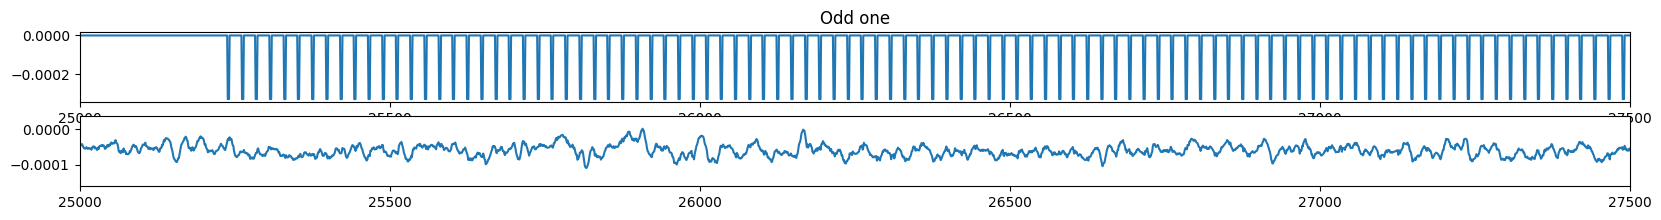

In [22]:
lower=25000
upper = lower+2500
plt.figure(figsize=(20, 2))
plt.subplot(211)
plt.plot(odd_one[19])
plt.xlim(lower, upper)
plt.title('Odd one')
plt.subplot(212)
plt.plot(odd_one[3])
plt.xlim(lower, upper)
plt.show()


In [27]:
for i, chunk in enumerate(photostim_chunks):
    print(f'Chunk {i} - Length: {chunk.shape[1]} - Frequency: {chunks_df.loc[i]["frequency"]}')

Chunk 0 - Length: 2550 - Frequency: 1
Chunk 1 - Length: 2550 - Frequency: 3
Chunk 2 - Length: 2550 - Frequency: 5
Chunk 3 - Length: 2550 - Frequency: 7
Chunk 4 - Length: 2550 - Frequency: 9
Chunk 5 - Length: 2550 - Frequency: 11
Chunk 6 - Length: 2550 - Frequency: 13
Chunk 7 - Length: 2550 - Frequency: 15
Chunk 8 - Length: 2550 - Frequency: 17
Chunk 9 - Length: 2550 - Frequency: 19
Chunk 10 - Length: 2550 - Frequency: 21
Chunk 11 - Length: 2550 - Frequency: 13
Chunk 12 - Length: 2550 - Frequency: 3
Chunk 13 - Length: 2550 - Frequency: 5
Chunk 14 - Length: 2550 - Frequency: 7
Chunk 15 - Length: 2550 - Frequency: 9
Chunk 16 - Length: 2550 - Frequency: 11
Chunk 17 - Length: 2550 - Frequency: 13
Chunk 18 - Length: 2550 - Frequency: 15
Chunk 19 - Length: 2550 - Frequency: 17
Chunk 20 - Length: 2550 - Frequency: 19
Chunk 21 - Length: 2550 - Frequency: 21
Chunk 22 - Length: 2550 - Frequency: 23
Chunk 23 - Length: 2550 - Frequency: 21
Chunk 24 - Length: 2550 - Frequency: 1
Chunk 25 - Length: 2

KeyError: 461

In [30]:
photostim_chunks_array=np.array(photostim_chunks)

np.save('photostimulation/data/photostim_steps.npy', photostim_chunks_array)
chunks_df.to_csv('photostimulation/data/photostim_steps.csv', index=False)

: 

In [ ]:
idx=11*11
plt.figure(figsize=(50,5))
plt.subplot(211)
plt.plot(photostim_chunks[idx][19])
plt.subplot(212)
plt.plot(photostim_chunks[idx][18])
plt.show()

In [ ]:
for i in range(len(photostim_chunks)):
    plt.figure(figsize=(20, 3))
    plt.suptitle(f'Sample {i}')
    plt.subplot(311)
    plt.plot(photostim_chunks[i][19])
    plt.subplot(312)
    plt.plot(photostim_chunks[i][18])
    plt.subplot(313)
    plt.plot(photostim_chunks[i][5])
    plt.show()